In [1]:
# 0. Preparación de ambientes necesarios

# Importar librerias
import pandas as pd
import xarray as xr
import numpy as np

import os
import errno
import geopandas as gpd
import seaborn as sns


import shapely
from shapely.geometry import shape, Polygon, Point, MultiPoint, box, LineString

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors

import cartopy
from cartopy import config
import cartopy.crs as ccrs
from cartopy.io.shapereader import Reader as sf
import cartopy.feature as cfeature


from mpl_toolkits.axes_grid1 import make_axes_locatable


from cmcrameri import cm

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.lines import Line2D
from cmcrameri import cm as ccm

In [37]:
from tc_size_rainfall.config import FIGURE_DIR, DATA_DIR, RAW_DIR, PROCESSED_DIR, OUTPUT_DIR
from tc_size_rainfall.geospatial import configurar_mapa

In [38]:
# ================================================================
# 1. Lectura de datos de precipitación agrupados
# ================================================================


pcp_mj_na = pd.read_csv( PROCESSED_DIR / "grouped" / 'na_mayo_junio.csv')
pcp_jas_na = pd.read_csv(PROCESSED_DIR / "grouped" / 'na_julio_sep.csv')
pcp_on_na = pd.read_csv(PROCESSED_DIR / "grouped" / 'na_oct_nov.csv')

pcp_mj_ep = pd.read_csv(PROCESSED_DIR / "grouped" / 'ep_mayo_junio.csv')
pcp_jas_ep = pd.read_csv(PROCESSED_DIR / "grouped" / 'ep_julio_sep.csv')
pcp_on_ep = pd.read_csv(PROCESSED_DIR / "grouped" / 'ep_oct_nov.csv')

# Combinar por temporada
pcp_mj = pd.concat([pcp_mj_na, pcp_mj_ep], ignore_index=True)
pcp_jas = pd.concat([pcp_jas_na, pcp_jas_ep], ignore_index=True)
pcp_on = pd.concat([pcp_on_na, pcp_on_ep], ignore_index=True)

# 1. DATA 

df_rocloud = pd.read_csv( RAW_DIR /'rocloud.csv', index_col=0)

# Extremos dentro de ciclones tropicales archivos para pacifico y atlantico
ext_na = pd.read_csv(PROCESSED_DIR / 'resultados_extremos_total_na.csv')
ext_ep = pd.read_csv(PROCESSED_DIR / 'resultados_extremos_total_ep.csv')
extremos = pd.concat([ext_na,ext_ep], ignore_index  =True)


In [28]:
df_mj = df_rocloud[df_rocloud.mm.isin([5,6])].copy()
df_js = df_rocloud[df_rocloud.mm.isin([7,8,9])].copy()
df_on = df_rocloud[df_rocloud.mm.isin([10,11])].copy()

In [7]:
# ================================================================
# 3. Funciones auxiliares
# ================================================================
def malla_r(binn, df, valor, op='mean'):
    # binn en km (111.1 km ≈ 1°)
    binn = binn / 111.1
    x = np.arange(-130, -60, binn)
    y = np.arange(5, 35, binn)
    xv, yv = np.meshgrid(x, y)
    if op == 'sum':
        grid = df[valor].groupby([
            pd.cut(df.lon, np.arange(-130, -60 + binn, binn)),
            pd.cut(df.lat, np.arange(5, 35 + binn, binn))
        ], observed=False).sum()
    else:
        grid = df[valor].groupby([
            pd.cut(df.lon, np.arange(-130, -60 + binn, binn)),
            pd.cut(df.lat, np.arange(5, 35 + binn, binn))
        ], observed=False).mean()

    gridnp = grid.reset_index()[valor].to_numpy().reshape((np.shape(xv)[1], np.shape(xv)[0]))
    return xv, yv, gridnp.T


def cmap_discret(vmin, vmax, steps=8, cmap=cm.devon_r):
    boundaries = np.linspace(vmin, vmax, steps)
    cmap_discreto = mcolors.ListedColormap(cmap(np.linspace(0, 1, len(boundaries)-1)))
    norm = mcolors.BoundaryNorm(boundaries, cmap_discreto.N)
    return boundaries, cmap_discreto, norm

In [ ]:
extremos = extremos.rename(columns = {'lat_p':'lat', 'lon_p':'lon'})

ext_mj = extremos[extremos.mm.isin([5,6])].copy()
ext_js = extremos[extremos.mm.isin([7,8,9])].copy()
ext_on = extremos[extremos.mm.isin([10,11])].copy()


In [22]:
ext_mj

,CT,mm,dd,hh,lat_cyclone,lon_cyclone,lat,lon,precip,p95_valor,cuadrante,r,MWS
0,AL012000,6,7,18,21.0,-93.0,20.25,-89.25,24.312500,21.312500,4,424.87674,46.25
1,AL012000,6,7,18,21.0,-93.0,16.95,-96.45,19.750000,19.062500,3,591.07886,46.25
2,AL012000,6,8,0,20.9,-92.8,20.35,-89.55,21.937500,21.250000,4,366.20972,46.25
3,AL012000,6,8,0,20.9,-92.8,20.35,-89.45,24.125000,20.437500,4,377.16833,46.25
4,AL012000,6,8,0,20.9,-92.8,20.35,-89.35,24.875000,20.125000,4,388.13556,46.25
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1321240,EP052021,6,30,0,23.5,-108.7,30.65,-111.35,15.441180,14.599995,2,847.16960,64.80
1321241,EP052021,6,30,0,23.5,-108.7,30.65,-111.15,17.725706,15.632812,2,839.70590,64.80
1321242,EP052021,6,30,0,23.5,-108.7,29.95,-105.75,9.879205,9.812500,1,787.98834,64.80
1321243,EP052021,6,30,0,23.5,-108.7,28.25,-109.75,26.880608,25.268738,2,540.46454,64.80


In [26]:
# ============================================================
# Promedio espacial por celda lat-lon para precipitación
# ============================================================

for name, df_ in {
    "ext_mj": ext_mj,
    "ext_js": ext_js,
    "ext_on": ext_on,
}.items():
    required_cols = {"lat", "lon", "precip"}
    missing_cols = required_cols - set(df_.columns)

    if missing_cols:
        raise ValueError(f"{name} no contiene las columnas requeridas: {missing_cols}")


ext_mj = (
    ext_mj
    .groupby(["lat", "lon"], as_index=False)["precip"]
    .mean()
)

ext_js = (
    ext_js
    .groupby(["lat", "lon"], as_index=False)["precip"]
    .mean()
)

ext_on = (
    ext_on
    .groupby(["lat", "lon"], as_index=False)["precip"]
    .mean()
)

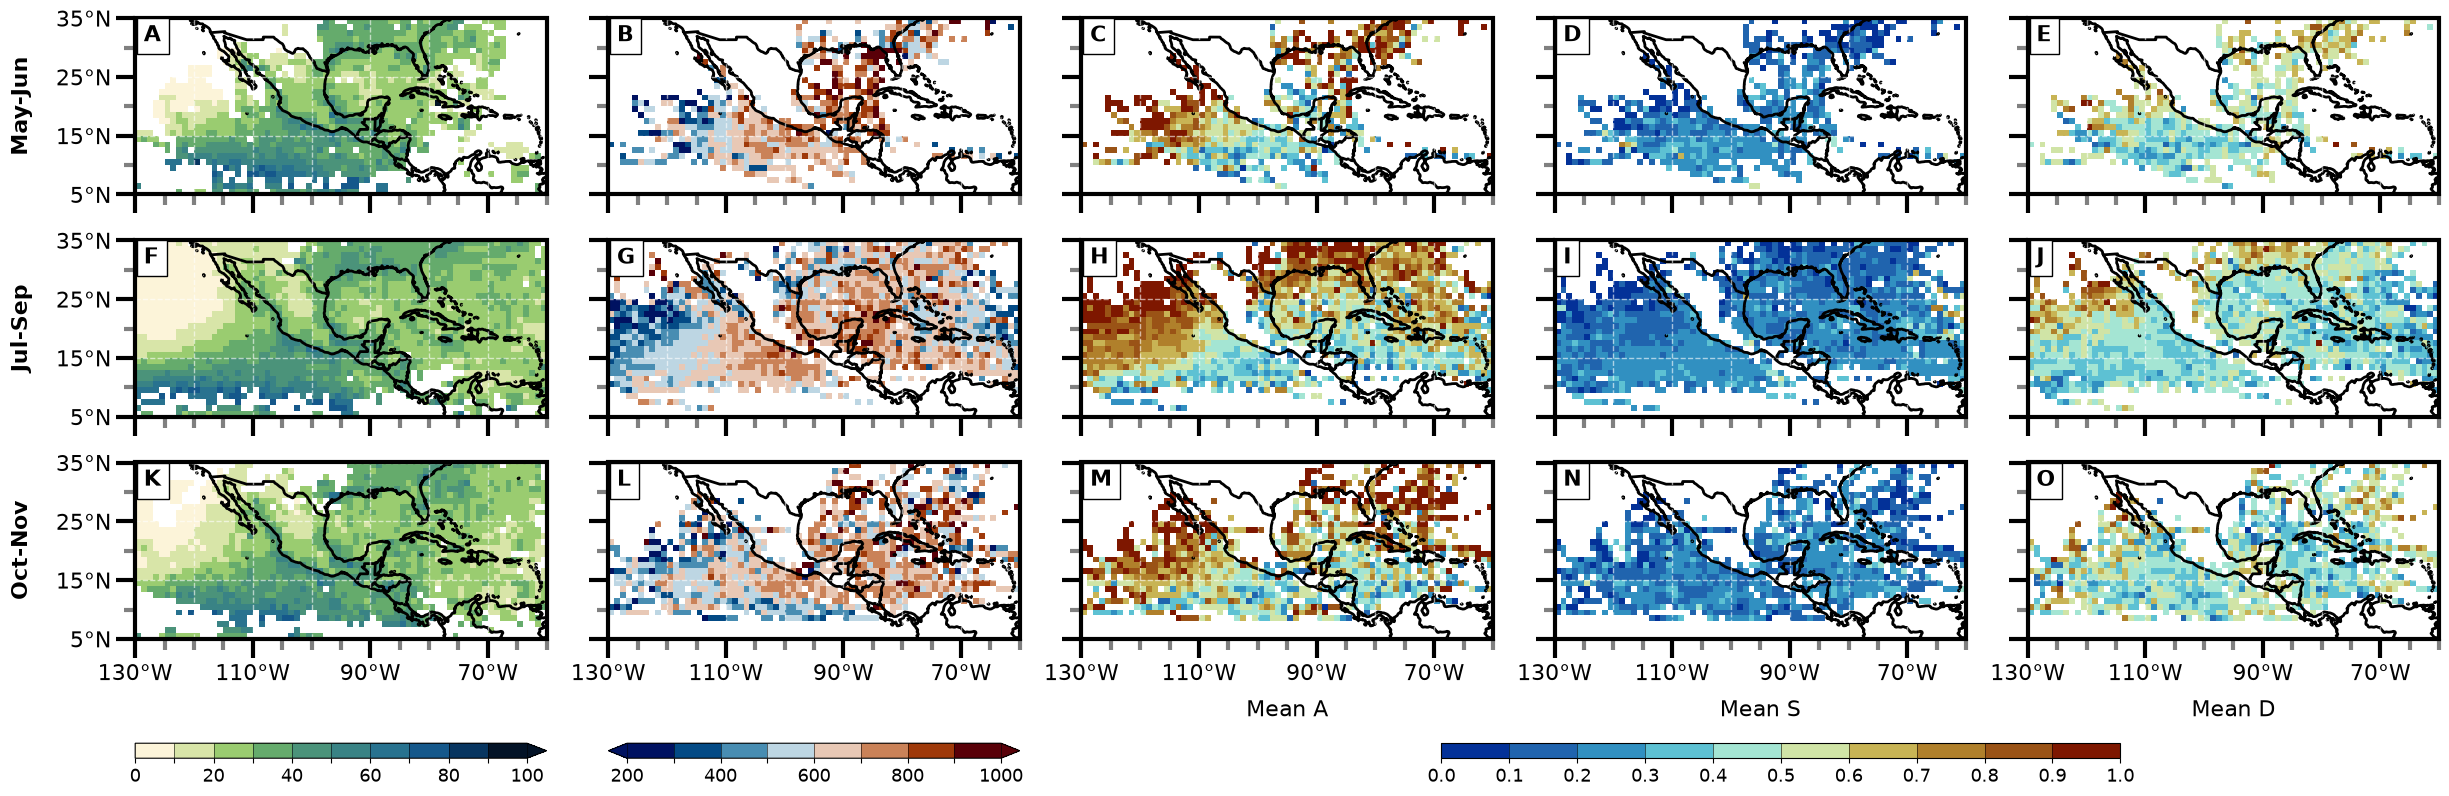

In [30]:
ext_mj# ================================================================
# 4. Crear figura 3x5 con mapas más grandes
# ================================================================
fig = plt.figure(figsize=(24, 10))  # 📏 Aumenta ligeramente el tamaño total de la figura
gs = gridspec.GridSpec(3, 5, wspace=0.15, hspace=-0.6)  # 📉 Reduce espacio horizontal y vertical

# Opcional: expandir el espacio útil de la figura (elimina márgenes exteriores innecesarios)
plt.subplots_adjust(left=0.02, right=0.98, top=1, bottom=0)

temporadas = ['May-Jun', 'Jul-Sep', 'Oct-Nov']
precip_dfs = [ext_mj, ext_js, ext_on]
cts_dfs = [df_mj, df_js, df_on]
variables = ['precip', 'Rp', 'A', 'S', 'D']
titulos = [' ', ' ', 'Mean A', 'Mean S', 'Mean D']
panel_labels = list("ABCDEFGHIJKLMNO")  # 15 paneles en total
contador = 0
# ================================================================
# 5. Bucle principal de mapas con colormaps personalizados
# ================================================================
for i, temporada in enumerate(temporadas):
    for j, var in enumerate(variables):
        ax = fig.add_subplot(gs[i, j], projection=ccrs.PlateCarree())

        # ============================
        # Configuración base del mapa
        # ============================
        configurar_mapa(
            ax,
            crs=ccrs.PlateCarree(),
            grid_spacing= 10,
            lon_extent=(-130, -60),
            land_color='w',
            lat_extent=(5, 35.1),
            lat_extent_begin=0,
            lon_tick_spacing=20,
            lat_tick_spacing=10,
            tick_width=3,
            tick_size=14,
            label_size=12
        )
        # ✅ Etiqueta de panel (A, B, C, …)
        ax.text(
            0.021, 0.958,                              # posición dentro del subplot
            rf'$\mathbf{{{panel_labels[contador]}}}$',  # letra correspondiente
            transform=ax.transAxes,
            fontsize=16,
            fontweight='bold',
            va='top',
            ha='left',
            bbox=dict(facecolor='w', edgecolor='k', pad=5.0),
            zorder=5
        )

        contador += 1  # Avanzamos la letra

        # ============================
        # Submarcas menores
        # ============================
        from matplotlib.ticker import MultipleLocator
        ax.xaxis.set_minor_locator(MultipleLocator(5))
        ax.yaxis.set_minor_locator(MultipleLocator(5))
        ax.tick_params(which='minor', length=8, width=3, color='gray', direction='out')

        # =====================================================
        # ✅ Mostrar etiquetas SOLO en el primer mapa de cada fila
        # =====================================================
        if j != 0:
            # Quitar etiquetas del eje Y en mapas que no sean la primera columna
            ax.set_yticklabels([])  
        if i != 2:
            # Quitar etiquetas del eje X en mapas que no sean la última fila
            ax.set_xticklabels([])

        # También puedes reducir el espacio de ticks para que se vean bien:
        ax.tick_params(axis='x', which='major', labelsize=16)
        ax.tick_params(axis='y', which='major', labelsize=16)

        # ============================
        # Selección de DataFrame y operación
        # ============================
        if var == 'precip':
            df_plot = precip_dfs[i]; op = 'mean'
        else:
            df_plot = cts_dfs[i]; op = 'mean'

        xv, yv, gridnpt = malla_r(111.11, df_plot, var, op=op)

        # ============================
        # Configuración de color
        # ============================
        if var == 'precip':
            cmap = cm.navia_r; vmin, vmax = 0, 100; bounds = np.arange(vmin, vmax + 10, 10)
        elif var == 'Rp':
            cmap = cm.vik; vmin, vmax = 200, 1000; bounds = np.arange(vmin, vmax + 100, 100)
        else:
            cmap = cm.roma_r; vmin, vmax = 0, 1; bounds = np.arange(vmin, vmax + 0.1, 0.1)

        norm = mcolors.BoundaryNorm(boundaries=bounds, ncolors=256)
        pcm = ax.pcolormesh(
            xv + 0.5, yv + 0.5, gridnpt,
            cmap=cmap, norm=norm, shading='auto',
            transform=ccrs.PlateCarree()
        )

        # Guardar para colorbars
        if var == 'precip':
            pcm_acum = pcm
        elif var == 'Rp':
            pcm_rp = pcm
        else:
            pcm_str = pcm

        # ============================
        # Títulos y etiquetas
        # ============================
        if i == 2:
            ax.set_title(titulos[j], fontsize=16, pad=8, y = -0.5)
        if j == 0:
            ax.text(-0.25, 0.5, temporada, va='center', ha='right', rotation=90,
                    transform=ax.transAxes, fontsize=16, fontweight='bold')
# ================================================================
# 6. Barras de color compartidas (una vez fuera del bucle)
# ================================================================

# -- 1. Acumulado --
cax_acum = fig.add_axes([gs[2, 0].get_position(fig).x0,
                         gs[2, 0].get_position(fig).y0+ 0.07 ,
                         gs[2, 0].get_position(fig).width,
                         0.015])

bounds_acum = np.arange(0, 100 + 10, 10)
cbar_acum = plt.colorbar(pcm_acum, cax=cax_acum, orientation='horizontal',
                         drawedges=True, extend='max',
                         boundaries=bounds_acum, ticks=bounds_acum)
# ✅ Mostrar solo uno sí y uno no
tick_labels = [str(int(v)) if idx % 2 == 0 else "" for idx, v in enumerate(bounds_acum)]
cbar_acum.set_ticks(bounds_acum)
cbar_acum.set_ticklabels(tick_labels)

# cbar_acum.set_label("Precipitación acumulada (mm)", fontsize=11)
cbar_acum.ax.tick_params(labelsize=13)


# -- 2. Rp --
cax_rp = fig.add_axes([gs[2, 1].get_position(fig).x0,
                       gs[2, 1].get_position(fig).y0+ 0.07 ,
                       gs[2, 1].get_position(fig).width,
                       0.015])

bounds_rp = np.arange(200, 1000 + 100, 100)
cbar_rp = plt.colorbar(pcm_rp, cax=cax_rp, orientation='horizontal',
                       drawedges=True, extend='both',
                       boundaries=bounds_rp, ticks=bounds_rp)
# ✅ Mostrar solo uno sí y uno no
tick_labels = [str(int(v)) if idx % 2 == 0 else "" for idx, v in enumerate(bounds_rp)]
cbar_rp.set_ticks(bounds_rp)
cbar_rp.set_ticklabels(tick_labels)


# cbar_rp.set_label("Radio promedio Rp (km)", fontsize=11)
cbar_rp.ax.tick_params(labelsize=13)

# -- 3. Métricas A, S, D --
cax_str = fig.add_axes([
                        gs[2, 2].get_position(fig).x0 + 0.15,   # desplazar ligeramente a la derecha
                        gs[2, 2].get_position(fig).y0 + 0.07 ,  # subir un poco para estética
                        (gs[2, 4].get_position(fig).x1 - gs[2, 2].get_position(fig).x0) * 0.5,  # reducir ancho al 60 %
                        0.015                                   # altura reducida (antes era 0.015)
                    ])

bounds_str = np.arange(0, 1.0 + 0.1, 0.1)
cbar_str = plt.colorbar(pcm_str, cax=cax_str, orientation='horizontal',
                        drawedges=True, #extend='max',
                        boundaries=bounds_str, ticks=bounds_str)
# cbar_str.set_label("Métricas estructurales A, S, D", fontsize=11)
cbar_str.ax.tick_params(labelsize=13)

# ================================================================
# 7. Guardar y mostrar figura
# ================================================================
# plt.savefig("FIG_FINAL_3x5.jpeg", dpi=300, bbox_inches='tight')
plt.show()